# Chapter 1 - Lab 1: API Calls - Open and closed-source LLMs

The objective of this lab is to demonstrate how to interact with both closed and open-source LLMs through API calls. While this step is relatively simple, it is foundational, particularly for those beginning to work in the field or aiming to develop AI agents that rely on external model access.


We will ask different LLMs to perform various tasks from summarizing Apple Q3 2025 earnings call (synthetically generated), to anwering to who is the winner of world cup 2022?


## Closed-source

### OpenAI

*   You need to create first an API Key and add some credits (5€ to 10€ suffise to start using with the API): https://platform.openai.com/docs/quickstart/step-2-set-up-your-api-key


In [1]:
%pip install openai -q

Add your OpenAI Key in Google colab:
* In the left vertical menu, you have an icon *key*.
* Click on it, and add your OpenAI key with a name.

In [2]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

In OpenAI, you have two ways to call LLMs:

1.   chat.completions (The legacy API):
https://platform.openai.com/docs/api-reference/chat/create

2.   responses (The new API): better to use this one directly: https://platform.openai.com/docs/api-reference/responses/create



In our lab, we will be using **Responses API** because this is the newest API that will replace chat.completions and Assistant AI API.

In [4]:
import json, textwrap, os

#### Earnings Call Transcript Apple Q3 2025:

In [5]:
# The following transcript earnings call is generated synthetically:

transcript_apple_earnings_call = """
# Synthetic Earnings Call Transcript – Apple (Example)

### Presentation

**Suhasini Chandramouli — Director of Investor Relations**

Good afternoon, and welcome to Apple’s Fiscal Q3 Earnings Conference Call. My name is Suhasini Chandramouli, Director of Investor Relations. Today’s call is being recorded.

Joining me on today’s call are Apple CEO Tim Cook and CFO Kevan Parekh. Following their prepared remarks, we will open the call for questions from analysts.

Please note that some of the information discussed today will include forward-looking statements, including statements regarding revenue outlook, product demand, services growth, supply chain conditions, and macroeconomic factors. These statements involve risks and uncertainties that may cause actual results to differ materially from those projected.

For more information, please refer to Apple’s filings with the U.S. Securities and Exchange Commission.

With that, I’ll turn the call over to Tim.

---

## Tim Cook — Chief Executive Officer

Thank you, Suhasini, and good afternoon to everyone joining us.

Today we are pleased to report **revenue of $98.7 billion**, up **6% year-over-year**, driven by strong demand across our product lineup and continued momentum in Services. **Diluted earnings per share were $1.72**, an increase of **9% compared to the same quarter last year**.

We saw particularly strong performance in emerging markets, including **India, Brazil, and Southeast Asia**, where Apple continues to expand both retail presence and developer ecosystems.

Let me walk through our major product categories.

### iPhone

Starting with iPhone. Revenue for the quarter was **$49.2 billion**, up **3% year-over-year**.

Customer response to the **iPhone 17 lineup** has been excellent, particularly the Pro models, which feature our new **A19 Pro chip**, enhanced on-device AI capabilities, and improved camera performance.

We are also seeing strong adoption of **Apple Intelligence features**, which help users write, summarize information, and interact with their devices more naturally.

### Mac

Moving to Mac. Revenue was **$8.6 billion**, up **10% year-over-year**.

Demand for Macs powered by the **M5 family of chips** continues to grow, especially among developers, creators, and AI researchers. The new **MacBook Air with M5** has quickly become the most popular laptop in its category.

### iPad

Revenue for iPad was **$6.8 billion**, up **12% year-over-year**.

The new **iPad Pro with the M4 chip** continues to be widely adopted in both education and enterprise environments, where its performance and portability are enabling entirely new workflows.

### Wearables, Home, and Accessories

Revenue in this category was **$7.3 billion**, down slightly year-over-year.

However, we continue to see strong engagement with **Apple Watch health features**, including sleep monitoring and cardiovascular insights.

### Services

Finally, Services delivered another **all-time revenue record of $28.4 billion**, up **14% year-over-year**.

Growth was driven by strong performance across the **App Store, Apple Music, Apple TV+, Apple Pay, and cloud services**.

Apple TV+ continues to gain momentum globally with new original series and films attracting record viewership.

Overall, we remain focused on innovation, privacy, and delivering experiences that enrich our customers’ lives.

With that, I’ll turn the call over to Kevan.

---

## Kevan Parekh — Chief Financial Officer

Thank you, Tim.

Our **gross margin for the quarter was 46.2%**, driven by a favorable product mix and continued growth in Services.

Operating expenses were **$14.5 billion**, reflecting continued investments in silicon engineering, AI infrastructure, and research and development.

We generated **$27 billion in operating cash flow** during the quarter and returned **$23 billion to shareholders** through share repurchases and dividends.

Looking ahead to next quarter, we expect:

* **Revenue growth in the mid-single-digit range**
* **Services growth in the low-to-mid teens**
* **Gross margin between 45% and 46%**

Despite macroeconomic uncertainty in some regions, we remain confident in the strength of Apple’s ecosystem and long-term growth opportunities.

With that, we’ll open the call to questions.

---

## Q&A Session

**Analyst — Morgan Stanley**

Could you elaborate on the adoption of Apple Intelligence features across the ecosystem?

**Tim Cook**

We’re seeing extremely strong engagement. Users appreciate having powerful AI capabilities that run **directly on-device**, preserving privacy while delivering meaningful productivity gains.

Developers are also integrating these capabilities into their apps, which we believe will accelerate innovation across the ecosystem.

---

**Analyst — Goldman Sachs**

Can you comment on Services growth and whether that momentum is sustainable?

**Kevan Parekh**

Services continues to benefit from the size of our installed base, which is now **well over two billion active devices**. As engagement across the ecosystem grows, we see increasing adoption of subscriptions, payments, and digital content.

---

**Suhasini Chandramouli**

Thank you for joining us today.

A replay of today’s call will be available on Apple’s Investor Relations website shortly.

Have a great day.

"""


**Responses API**

In [8]:
from openai import OpenAI
client = OpenAI(api_key = OPENAI_API_KEY)

system_prompt = """You are a finance analyst. Produce a concise, decision-useful summary of an
earnings call for portfolio managers. Return strict JSON with keys:
company, quarter, revenue, eps, guidance, highlights[], risks[], outlook."""

user_prompt = f"""Summarize the following earnings call transcript:
{transcript_apple_earnings_call}"""

response = client.responses.create(
  model="gpt-4.1-mini",
  input=[{"role":"system","content":system_prompt},{"role":"user","content":user_prompt}],
  text = {"format":{"type": "json_object"}},
)

print(json.dumps(json.loads(response.output[0].content[0].text), indent=2))

#https://platform.openai.com/docs/api-reference/responses/create

{
  "company": "Apple",
  "quarter": "Fiscal Q3",
  "revenue": 98700000000,
  "eps": 1.72,
  "guidance": {
    "revenue_growth": "mid-single-digit range",
    "services_growth": "low-to-mid teens",
    "gross_margin": "45% to 46%"
  },
  "highlights": [
    "Revenue increased 6% year-over-year to $98.7 billion",
    "EPS grew 9% year-over-year to $1.72",
    "Strong iPhone revenue of $49.2 billion, up 3%, driven by iPhone 17 Pro models with A19 Pro chip and enhanced AI",
    "Mac revenue rose 10% to $8.6 billion, driven by M5 chip-powered devices, especially MacBook Air",
    "iPad revenue grew 12% to $6.8 billion, led by iPad Pro with M4 chip adoption in education and enterprise",
    "Wearables, Home, and Accessories revenue of $7.3 billion, slightly down year-over-year, with strong Apple Watch health feature engagement",
    "Services set an all-time revenue record of $28.4 billion, up 14%, driven by App Store, Apple Music, Apple TV+, Apple Pay, and cloud services",
    "Gross margi

### Google - Gemini

Now let's try Google Gemini to summarize the same earnings call transcript from Apple Q3 2025 (Generated synthetically)

 You can have the list of Gemini models here:

https://ai.google.dev/gemini-api/docs/models



 To access these models via the google-genai package, you will need to create an API key through the Google Developer Console.

 For now, certains models are available under a free API usage plan for experimental usage.

In [9]:
# %pip install google-generativeai -q
%pip install google-genai -q

In [11]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [ ]:
# transcript_apple_earnings_call = """
# # Synthetic Earnings Call Transcript – Apple (Example)

# ### Presentation

# **Suhasini Chandramouli — Director of Investor Relations**

# Good afternoon, and welcome to Apple’s Fiscal Q3 Earnings Conference Call. My name is Suhasini Chandramouli, Director of Investor Relations. Today’s call is being recorded.

# Joining me on today’s call are Apple CEO Tim Cook and CFO Kevan Parekh. Following their prepared remarks, we will open the call for questions from analysts.

# Please note that some of the information discussed today will include forward-looking statements, including statements regarding revenue outlook, product demand, services growth, supply chain conditions, and macroeconomic factors. These statements involve risks and uncertainties that may cause actual results to differ materially from those projected.

# For more information, please refer to Apple’s filings with the U.S. Securities and Exchange Commission.

# With that, I’ll turn the call over to Tim.

# ---

# ## Tim Cook — Chief Executive Officer

# Thank you, Suhasini, and good afternoon to everyone joining us.

# Today we are pleased to report **revenue of $98.7 billion**, up **6% year-over-year**, driven by strong demand across our product lineup and continued momentum in Services. **Diluted earnings per share were $1.72**, an increase of **9% compared to the same quarter last year**.

# We saw particularly strong performance in emerging markets, including **India, Brazil, and Southeast Asia**, where Apple continues to expand both retail presence and developer ecosystems.

# Let me walk through our major product categories.

# ### iPhone

# Starting with iPhone. Revenue for the quarter was **$49.2 billion**, up **3% year-over-year**.

# Customer response to the **iPhone 17 lineup** has been excellent, particularly the Pro models, which feature our new **A19 Pro chip**, enhanced on-device AI capabilities, and improved camera performance.

# We are also seeing strong adoption of **Apple Intelligence features**, which help users write, summarize information, and interact with their devices more naturally.

# ### Mac

# Moving to Mac. Revenue was **$8.6 billion**, up **10% year-over-year**.

# Demand for Macs powered by the **M5 family of chips** continues to grow, especially among developers, creators, and AI researchers. The new **MacBook Air with M5** has quickly become the most popular laptop in its category.

# ### iPad

# Revenue for iPad was **$6.8 billion**, up **12% year-over-year**.

# The new **iPad Pro with the M4 chip** continues to be widely adopted in both education and enterprise environments, where its performance and portability are enabling entirely new workflows.

# ### Wearables, Home, and Accessories

# Revenue in this category was **$7.3 billion**, down slightly year-over-year.

# However, we continue to see strong engagement with **Apple Watch health features**, including sleep monitoring and cardiovascular insights.

# ### Services

# Finally, Services delivered another **all-time revenue record of $28.4 billion**, up **14% year-over-year**.

# Growth was driven by strong performance across the **App Store, Apple Music, Apple TV+, Apple Pay, and cloud services**.

# Apple TV+ continues to gain momentum globally with new original series and films attracting record viewership.

# Overall, we remain focused on innovation, privacy, and delivering experiences that enrich our customers’ lives.

# With that, I’ll turn the call over to Kevan.

# ---

# ## Kevan Parekh — Chief Financial Officer

# Thank you, Tim.

# Our **gross margin for the quarter was 46.2%**, driven by a favorable product mix and continued growth in Services.

# Operating expenses were **$14.5 billion**, reflecting continued investments in silicon engineering, AI infrastructure, and research and development.

# We generated **$27 billion in operating cash flow** during the quarter and returned **$23 billion to shareholders** through share repurchases and dividends.

# Looking ahead to next quarter, we expect:

# * **Revenue growth in the mid-single-digit range**
# * **Services growth in the low-to-mid teens**
# * **Gross margin between 45% and 46%**

# Despite macroeconomic uncertainty in some regions, we remain confident in the strength of Apple’s ecosystem and long-term growth opportunities.

# With that, we’ll open the call to questions.

# ---

# ## Q&A Session

# **Analyst — Morgan Stanley**

# Could you elaborate on the adoption of Apple Intelligence features across the ecosystem?

# **Tim Cook**

# We’re seeing extremely strong engagement. Users appreciate having powerful AI capabilities that run **directly on-device**, preserving privacy while delivering meaningful productivity gains.

# Developers are also integrating these capabilities into their apps, which we believe will accelerate innovation across the ecosystem.

# ---

# **Analyst — Goldman Sachs**

# Can you comment on Services growth and whether that momentum is sustainable?

# **Kevan Parekh**

# Services continues to benefit from the size of our installed base, which is now **well over two billion active devices**. As engagement across the ecosystem grows, we see increasing adoption of subscriptions, payments, and digital content.

# ---

# **Suhasini Chandramouli**

# Thank you for joining us today.

# A replay of today’s call will be available on Apple’s Investor Relations website shortly.

# Have a great day.
# """

In the system prompt, I specified to the LLM that I want to have the summary in a JSON format and I give a list of keys I want to extract from the earnings call transcipt.

In [12]:
system_prompt = """You are a finance analyst. Produce a concise, decision-useful summary of an
earnings call for portfolio managers. Return strict JSON with keys:
company, quarter, revenue, eps, guidance, highlights[], risks[], outlook."""

user_prompt = f"""Summarize the following earnings call transcript:
{transcript_apple_earnings_call}"""


In [13]:
from google import genai

# os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
# genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
# client = genai.Client()

client = genai.Client(api_key=GOOGLE_API_KEY)

resp_genai = client.models.generate_content(
    model = "gemini-2.5-flash",
    contents = system_prompt + "\n\n" + user_prompt,
    config = {
        "response_mime_type": "application/json",
    },
)

print(resp_genai.text)

#Reasoning is enabled by default ==> to disable it have a look on the docuementation: https://ai.google.dev/gemini-api/docs/thinking
# thinking_config=types.ThinkingConfig(thinking_budget=-1) to have a dynamic thinking, meaning that the model will adjust thinking based on the complexity of the task

# If you have this error, try again, it's not an issue from your side but from Google side:
#ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'The model is overloaded. Please try again later.', 'status': 'UNAVAILABLE'}}

{
  "company": "Apple",
  "quarter": "Fiscal Q3",
  "revenue": "$98.7B (+6% YoY)",
  "eps": "$1.72 (+9% YoY)",
  "guidance": "Next quarter: Revenue mid-single-digit growth, Services low-to-mid teens growth, Gross margin 45-46%.",
  "highlights": [
    "Record Services revenue ($28.4B, +14% YoY) driven by App Store, Apple Music, Apple TV+, Apple Pay, and cloud services.",
    "Strong product demand: iPhone (+3%), Mac (+10%), and iPad (+12%) with positive reception for new models (iPhone 17 Pro, M5 Macs, M4 iPad Pro).",
    "Significant growth in emerging markets including India, Brazil, and Southeast Asia.",
    "Strong adoption and engagement with on-device Apple Intelligence features, enhancing privacy and productivity.",
    "Gross margin of 46.2% driven by favorable product mix and continued Services growth.",
    "$27B in operating cash flow generated, with $23B returned to shareholders.",
    "Installed base now exceeds two billion active devices, underpinning sustainable Services

In [14]:
resp_genai

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""{
  "company": "Apple",
  "quarter": "Fiscal Q3",
  "revenue": "$98.7B (+6% YoY)",
  "eps": "$1.72 (+9% YoY)",
  "guidance": "Next quarter: Revenue mid-single-digit growth, Services low-to-mid teens growth, Gross margin 45-46%.",
  "highlights": [
    "Record Services revenue ($28.4B, +14% YoY) driven by App Store, Apple Music, Apple TV+, Apple Pay, and cloud services.",
    "Strong product demand: iPhone (+3%), Mac (+10%), and iPad (+12%) with positive reception for new models (iPhone 17 Pro, M5 Macs, M4 iPad Pro).",
    "Significant growth in emerging markets including India, Brazil, and Southeast Asia.",
    "Strong adoption and engagement with on-device Apple Intelligence features, enhancing privacy and productivity.",
    "Gross margin of 46.2% driven by favorable product mix and continued Services growth.",
    

### Anthropic

In this section of the notebook, we use Anthropic API and request the LLM to summarize the same earnings call transcript than in the previous sections.



*   You can use the various models in Anthropic such as Clause 4 or 4.6 (Sonnet, Opus, Haiku (4.5)):
https://docs.anthropic.com/en/api/messages

*   You need to create first an API Key and add some credits (5€ to 10€ suffise to start using with the API):

Create an account + go to Account Settings to create an API and add credits:

https://console.anthropic.com/settings/keys





In [25]:
!pip install anthropic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 19.1 MB/s eta 0:00:00


In [26]:
from google.colab import userdata
ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')

In [28]:
import anthropic

client = anthropic.Anthropic(
    # defaults to os.environ.get("ANTHROPIC_API_KEY")
    api_key=ANTHROPIC_API_KEY,
)

system_prompt = """You are a finance analyst. Produce a concise, decision-useful summary of an
earnings call for portfolio managers. Return strict JSON with keys:
company, quarter, revenue, eps, guidance, highlights[], risks[], outlook."""

user_prompt = f"""Summarize the following earnings call transcript:
{transcript_apple_earnings_call}"""

message = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=1024,
    messages=[{"role": "user", "content": system_prompt + "\n\n" + user_prompt}]
)
print(message.content)

[TextBlock(citations=None, text='```json\n{\n  "company": "Apple Inc.",\n  "quarter": "Q3 Fiscal",\n  "revenue": {\n    "total": "$98.7 billion",\n    "growth": "6% year-over-year"\n  },\n  "eps": {\n    "diluted": "$1.72",\n    "growth": "9% year-over-year"\n  },\n  "guidance": {\n    "revenue_growth": "mid-single-digit range",\n    "services_growth": "low-to-mid teens",\n    "gross_margin": "45% to 46%"\n  },\n  "highlights": [\n    "Services hit all-time revenue record of $28.4B (+14% YoY)",\n    "Strong iPhone 17 Pro demand with A19 Pro chip and Apple Intelligence features",\n    "Mac revenue up 10% YoY driven by M5 chip adoption",\n    "iPad revenue up 12% YoY with M4 iPad Pro gaining traction",\n    "Strong performance in emerging markets including India, Brazil, and Southeast Asia",\n    "Generated $27B operating cash flow and returned $23B to shareholders",\n    "Installed base exceeds 2 billion active devices"\n  ],\n  "risks": [\n    "Macroeconomic uncertainty in some regions

In [31]:
str_json = message.content[0].text
clean_str = str_json.strip("```json").strip("```").strip()
final_output = json.loads(clean_str)
final_output

{'company': 'Apple Inc.',
 'quarter': 'Q3 Fiscal',
 'revenue': {'total': '$98.7 billion', 'growth': '6% year-over-year'},
 'eps': {'diluted': '$1.72', 'growth': '9% year-over-year'},
 'guidance': {'revenue_growth': 'mid-single-digit range',
  'services_growth': 'low-to-mid teens',
  'gross_margin': '45% to 46%'},
 'highlights': ['Services hit all-time revenue record of $28.4B (+14% YoY)',
  'Strong iPhone 17 Pro demand with A19 Pro chip and Apple Intelligence features',
  'Mac revenue up 10% YoY driven by M5 chip adoption',
  'iPad revenue up 12% YoY with M4 iPad Pro gaining traction',
  'Strong performance in emerging markets including India, Brazil, and Southeast Asia',
  'Generated $27B operating cash flow and returned $23B to shareholders',
  'Installed base exceeds 2 billion active devices'],
 'risks': ['Macroeconomic uncertainty in some regions',
  'Wearables revenue declined slightly year-over-year',
  'Forward-looking statements subject to material risks and uncertainties'],
 '

The output from the API call is a json format as requested in the prompt.

## Hugging Face - Open Source



*   You need to connect to Hugging Face and create your API key. I've called mine: HF_TOKEN:

    - https://huggingface.co/docs/hub/security-tokens

*   You need also to request access to the LLM in HF:

    - You choose your model in: https://huggingface.co/models

    - For example: https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct

    - In the model card, you have also a code snippet on how to call the model using Python


Mounted at /content/drive


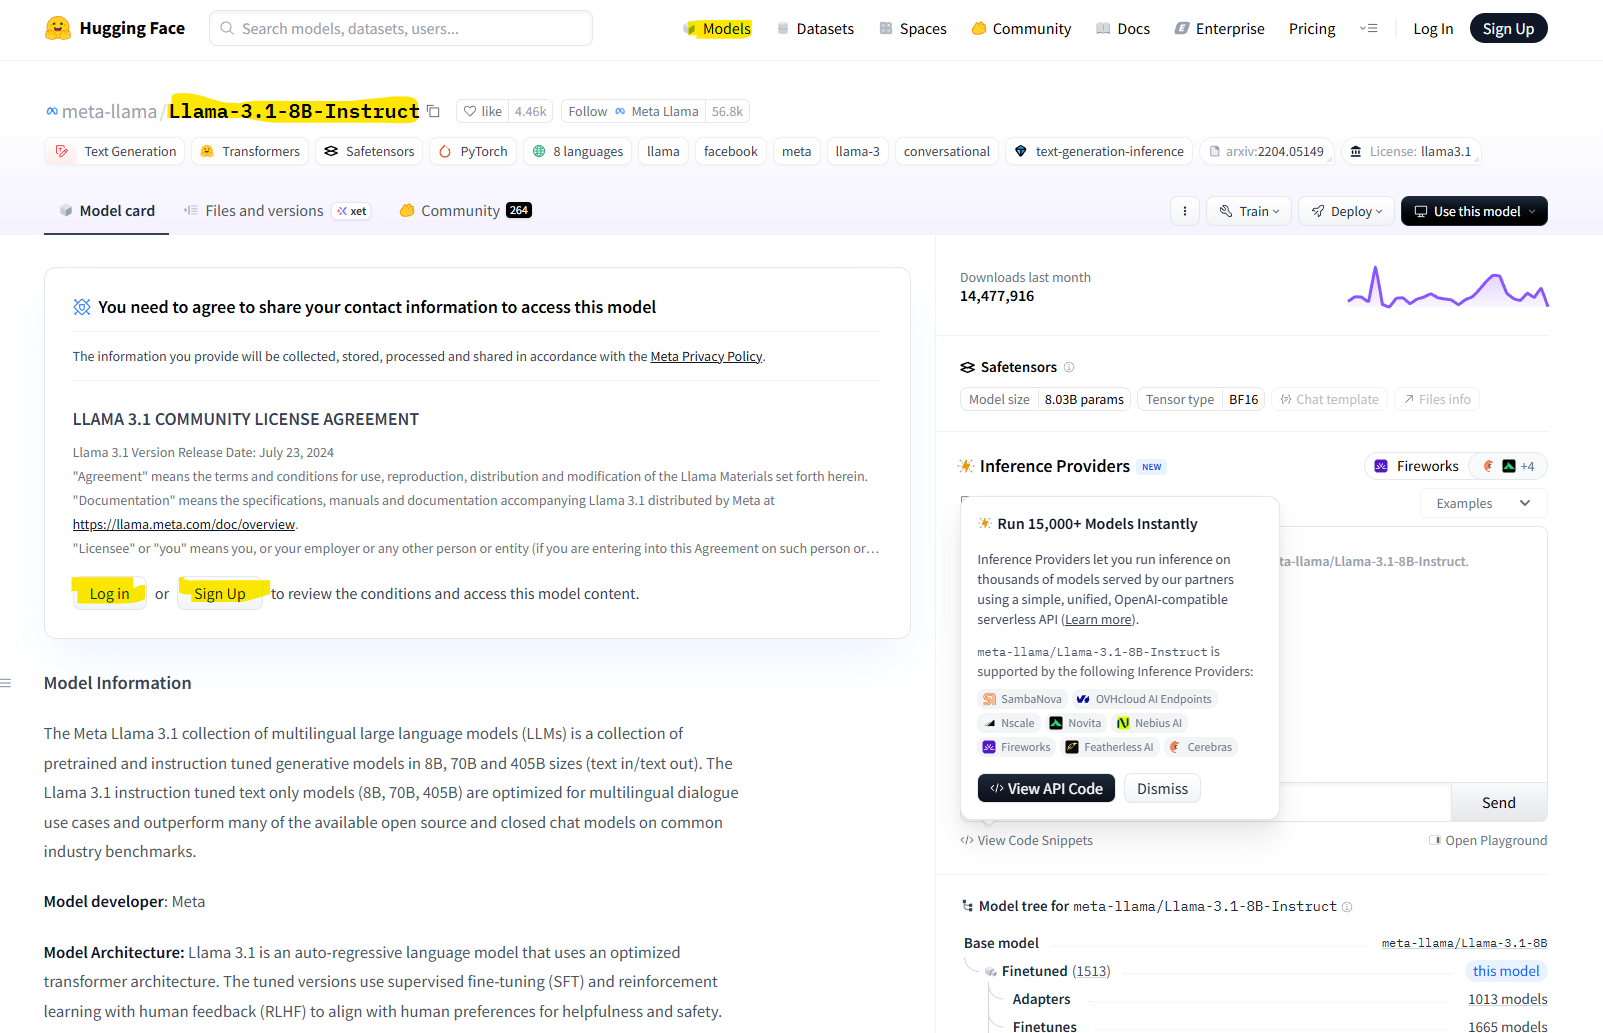

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# local_path=

from IPython.display import Image, display
image_path = local_path+"hf_model_access.png"
display(Image(filename=image_path))


### Llama-3.1-8B-Instruct

Loading the model from Transformers lib will take place.

In Google Colab, you can choose in the menu at the top of the page in the "**Runtime**" tab ==> "**change the runtime type**" ==> Choose "**T4 GPU**" ==> So you can have access to a free GPU to load and work with an SLM.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer

model_id = "meta-llama/Llama-3.1-8B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer

# model_id = "meta-llama/Llama-3.1-8B-Instruct"
# model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

prompt = "Who is the winner of the World Cup 2022?"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
input_ids = input_ids.to('cuda')
output = model.generate(input_ids)

response = tokenizer.decode(output[0], skip_special_tokens=True)

from IPython.display import display, Markdown
display(Markdown(response))

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Who is the winner of World Cup 2022? Argentina won the 2022 FIFA World Cup by defeating France 4-2 in a penalty shootout

**Result**

`Who is the winner of World Cup 2022?`

> Argentina won the 2022 FIFA World Cup by defeating France 4-2 in a penalty shootout



We get the right answer to our question using Llama 3.1 8B

### Llama-3.1-8B-Instruct with Pipeline

You can also use the pipeline object from the Transformers library, which aggregates the model call, handles tokenization, encodes the input and decodes the output, all in a single operation:

In [ ]:
import transformers
import torch

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

messages = [
    {"role": "user", "content": "Who was the winner of the World Cup 2022?"},
]

outputs = pipeline(
    messages,
    max_new_tokens=256,
)
print(outputs[0]["generated_text"][-1])


In [ ]:
import transformers
import torch

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

messages = [
    {"role": "user", "content": "Who was the winner of the World Cup 2022?"},
]

outputs = pipeline(
    messages,
    max_new_tokens=256,
)
print(outputs[0]["generated_text"][-1])


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


{'role': 'assistant', 'content': 'Argentina won the 2022 FIFA World Cup, which was held in Qatar. They defeated France 4-2 in a penalty shootout after the match ended 3-3 after extra time in the final on December 18, 2022.'}


A second call to check consistency of the output

In [ ]:
import transformers
import torch

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

messages = [
    {"role": "user", "content": "Who was the winner of the World Cup 2022?"},
]

outputs = pipeline(
    messages,
    max_new_tokens=256,
)
print(outputs[0]["generated_text"][-1])


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


{'role': 'assistant', 'content': 'The winner of the 2022 FIFA World Cup was Argentina. They defeated France in the final with a score of 4-2 in a penalty shootout after the game ended 3-3 after extra time.'}


Now let's try the model with earnings call transcript summarization task:

In [ ]:
# The following transcript earnings call is generated synthetically:

transcript_apple_earnings_call = """
# Synthetic Earnings Call Transcript – Apple (Example)

### Presentation

**Suhasini Chandramouli — Director of Investor Relations**

Good afternoon, and welcome to Apple’s Fiscal Q3 Earnings Conference Call. My name is Suhasini Chandramouli, Director of Investor Relations. Today’s call is being recorded.

Joining me on today’s call are Apple CEO Tim Cook and CFO Kevan Parekh. Following their prepared remarks, we will open the call for questions from analysts.

Please note that some of the information discussed today will include forward-looking statements, including statements regarding revenue outlook, product demand, services growth, supply chain conditions, and macroeconomic factors. These statements involve risks and uncertainties that may cause actual results to differ materially from those projected.

For more information, please refer to Apple’s filings with the U.S. Securities and Exchange Commission.

With that, I’ll turn the call over to Tim.

---

## Tim Cook — Chief Executive Officer

Thank you, Suhasini, and good afternoon to everyone joining us.

Today we are pleased to report **revenue of $98.7 billion**, up **6% year-over-year**, driven by strong demand across our product lineup and continued momentum in Services. **Diluted earnings per share were $1.72**, an increase of **9% compared to the same quarter last year**.

We saw particularly strong performance in emerging markets, including **India, Brazil, and Southeast Asia**, where Apple continues to expand both retail presence and developer ecosystems.

Let me walk through our major product categories.

### iPhone

Starting with iPhone. Revenue for the quarter was **$49.2 billion**, up **3% year-over-year**.

Customer response to the **iPhone 17 lineup** has been excellent, particularly the Pro models, which feature our new **A19 Pro chip**, enhanced on-device AI capabilities, and improved camera performance.

We are also seeing strong adoption of **Apple Intelligence features**, which help users write, summarize information, and interact with their devices more naturally.

### Mac

Moving to Mac. Revenue was **$8.6 billion**, up **10% year-over-year**.

Demand for Macs powered by the **M5 family of chips** continues to grow, especially among developers, creators, and AI researchers. The new **MacBook Air with M5** has quickly become the most popular laptop in its category.

### iPad

Revenue for iPad was **$6.8 billion**, up **12% year-over-year**.

The new **iPad Pro with the M4 chip** continues to be widely adopted in both education and enterprise environments, where its performance and portability are enabling entirely new workflows.

### Wearables, Home, and Accessories

Revenue in this category was **$7.3 billion**, down slightly year-over-year.

However, we continue to see strong engagement with **Apple Watch health features**, including sleep monitoring and cardiovascular insights.

### Services

Finally, Services delivered another **all-time revenue record of $28.4 billion**, up **14% year-over-year**.

Growth was driven by strong performance across the **App Store, Apple Music, Apple TV+, Apple Pay, and cloud services**.

Apple TV+ continues to gain momentum globally with new original series and films attracting record viewership.

Overall, we remain focused on innovation, privacy, and delivering experiences that enrich our customers’ lives.

With that, I’ll turn the call over to Kevan.

---

## Kevan Parekh — Chief Financial Officer

Thank you, Tim.

Our **gross margin for the quarter was 46.2%**, driven by a favorable product mix and continued growth in Services.

Operating expenses were **$14.5 billion**, reflecting continued investments in silicon engineering, AI infrastructure, and research and development.

We generated **$27 billion in operating cash flow** during the quarter and returned **$23 billion to shareholders** through share repurchases and dividends.

Looking ahead to next quarter, we expect:

* **Revenue growth in the mid-single-digit range**
* **Services growth in the low-to-mid teens**
* **Gross margin between 45% and 46%**

Despite macroeconomic uncertainty in some regions, we remain confident in the strength of Apple’s ecosystem and long-term growth opportunities.

With that, we’ll open the call to questions.

---

## Q&A Session

**Analyst — Morgan Stanley**

Could you elaborate on the adoption of Apple Intelligence features across the ecosystem?

**Tim Cook**

We’re seeing extremely strong engagement. Users appreciate having powerful AI capabilities that run **directly on-device**, preserving privacy while delivering meaningful productivity gains.

Developers are also integrating these capabilities into their apps, which we believe will accelerate innovation across the ecosystem.

---

**Analyst — Goldman Sachs**

Can you comment on Services growth and whether that momentum is sustainable?

**Kevan Parekh**

Services continues to benefit from the size of our installed base, which is now **well over two billion active devices**. As engagement across the ecosystem grows, we see increasing adoption of subscriptions, payments, and digital content.

---

**Suhasini Chandramouli**

Thank you for joining us today.

A replay of today’s call will be available on Apple’s Investor Relations website shortly.

Have a great day.

"""

In [16]:
system_prompt = """You are a finance analyst. Produce a concise, decision-useful summary of an
earnings call for portfolio managers. Return strict JSON with keys:
company, quarter, revenue, eps, guidance, highlights[], risks[], outlook."""

user_prompt = f"""Summarize the following earnings call transcript:
{transcript_apple_earnings_call}"""

In [17]:
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_prompt},
]

outputs = pipeline(
    messages,
)
print(outputs[0]["generated_text"][-1])

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'role': 'assistant', 'content': '```json\n{\n  "company": "Apple",\n  "quarter": "Fiscal Q3",\n  "revenue": "$98.7 billion",\n  "eps": "$1.72",\n  "guidance": {\n    "revenue": "mid-single-digit range",\n    "services": "low-to-mid teens",\n    "gross margin": "45%-46%"\n  },\n  "highlights": [\n    "Revenue up 6% year-over-year",\n    "Services growth at 14% year-over-year",\n    "Strong performance in emerging markets",\n    "iPhone 17 lineup drives customer response",\n    "M5 family of chips powers growth in Mac sales",\n    "Apple TV+ gains momentum globally"\n  ],\n  "risks": [\n    "Macroeconomic uncertainty in some regions",\n    "Supply chain conditions",\n    "Global economic downturn"\n  ],\n  "outlook": "Remain confident in Apple\'s ecosystem and long-term growth opportunities"\n}\n```\n\nThis JSON object summarizes the key points from the earnings call, including the company\'s revenue, EPS, guidance for the next quarter, highlights from the quarter, potential risks, and 

In [18]:
print(outputs[0]["generated_text"][-1]['content'])

```json
{
  "company": "Apple",
  "quarter": "Fiscal Q3",
  "revenue": "$98.7 billion",
  "eps": "$1.72",
  "guidance": {
    "revenue": "mid-single-digit range",
    "services": "low-to-mid teens",
    "gross margin": "45%-46%"
  },
  "highlights": [
    "Revenue up 6% year-over-year",
    "Services growth at 14% year-over-year",
    "Strong performance in emerging markets",
    "iPhone 17 lineup drives customer response",
    "M5 family of chips powers growth in Mac sales",
    "Apple TV+ gains momentum globally"
  ],
  "risks": [
    "Macroeconomic uncertainty in some regions",
    "Supply chain conditions",
    "Global economic downturn"
  ],
  "outlook": "Remain confident in Apple's ecosystem and long-term growth opportunities"
}
```

This JSON object summarizes the key points from the earnings call, including the company's revenue, EPS, guidance for the next quarter, highlights from the quarter, potential risks, and overall outlook.


In [19]:
outputs

[{'generated_text': [{'role': 'system',
    'content': 'You are a finance analyst. Produce a concise, decision-useful summary of an\nearnings call for portfolio managers. Return strict JSON with keys:\ncompany, quarter, revenue, eps, guidance, highlights[], risks[], outlook.'},
   {'role': 'user',
    'content': 'Summarize the following earnings call transcript:\n\n\n\n# Synthetic Earnings Call Transcript – Apple (Example)\n\n### Presentation\n\n**Suhasini Chandramouli — Director of Investor Relations**\n\nGood afternoon, and welcome to Apple’s Fiscal Q3 Earnings Conference Call. My name is Suhasini Chandramouli, Director of Investor Relations. Today’s call is being recorded.\n\nJoining me on today’s call are Apple CEO Tim Cook and CFO Kevan Parekh. Following their prepared remarks, we will open the call for questions from analysts.\n\nPlease note that some of the information discussed today will include forward-looking statements, including statements regarding revenue outlook, produc

## Reasoning Model

Let's try a reasoning model with OpenAI : The latest one GPT-5. We'll as to summarize the earnings call transcript.

The goal is to show the quality of the outputs of these models.


Here are some parameters you can control the:

↳ **Reasoning mode** in the API:

 ▪️ 4 options: **low, medium, high and minimal**

 - Low favored speed and fewer tokens, while high favored more thorough reasoning. (from low to high is like o3)

 - Minimal: new setting ==> Produces very few reasoning tokens for cases where you need the fastest possible time-to-first-token.

 ▪️reasoning={
 "effort": "minimal"
 }

 ▪️ They are not using the same parameter names between chatcompletion and responses API.


↳ **Verbosity**:

 ▪️Control the number of tokens generated by the model (not only the reasoning steps, but the whole answer)

 ▪️3 options: **low, medium, high**. Before GPT-5, models have default value = medium

 ▪️text={
 "verbosity": "low"
 }

Key remarrk: Controlling the reasoning and the verbosity will help control the tokens costs when calling LLMs, especially when building with

Now, let's specify the system and user prompts:

In [20]:
system_prompt = """You are a finance analyst. Produce a concise, decision-useful summary of an
earnings call for portfolio managers. Return strict JSON with keys:
company, quarter, revenue, eps, guidance, highlights[], risks[], outlook."""

user_prompt = f"""Summarize the following earnings call transcript:
{transcript_apple_earnings_call}"""

In [22]:
from openai import OpenAI

client = OpenAI(api_key = OPENAI_API_KEY)

resp_reasoning = client.responses.create(
  model="gpt-5",
  input=[{"role":"system","content":system_prompt},{"role":"user","content":user_prompt}],
  text = {"format":{"type": "json_object"}, "verbosity": "low"},

  reasoning={
        "effort": "minimal"
    },
)

#final answer:
print(json.dumps(json.loads(resp_reasoning.output[1].content[0].text), indent=2))

{
  "company": "Apple",
  "quarter": "Fiscal Q3",
  "revenue": "$98.7B (+6% Y/Y)",
  "eps": "$1.72 (+9% Y/Y)",
  "guidance": {
    "revenue": "Mid-single-digit Y/Y growth next quarter",
    "services": "Low-to-mid teens growth next quarter",
    "gross_margin": "45%\u201346% next quarter"
  },
  "highlights": [
    "iPhone revenue $49.2B (+3% Y/Y); strong iPhone 17 Pro demand, A19 Pro and on-device AI features",
    "Mac revenue $8.6B (+10% Y/Y); M5 Macs gaining traction, MacBook Air leading category",
    "iPad revenue $6.8B (+12% Y/Y); M4 iPad Pro adoption in education and enterprise",
    "Wearables/Home/Accessories $7.3B (slightly down Y/Y); strong Apple Watch health engagement",
    "Services record $28.4B (+14% Y/Y); strength in App Store, Music, TV+, Pay, cloud",
    "Gross margin 46.2%; OpEx $14.5B focused on silicon and AI; $27B OCF; $23B capital return",
    "Strong growth in emerging markets: India, Brazil, Southeast Asia",
    "Installed base well over 2B active devices; ri

As you can see, the quality of the results is significantly higher, compared to the other models, particularly in the "Highlights" section, which requires deeper reasoning to produce meaningful insights.